# A foundational introduction to **naima**

This notebook explains, from the ground up, what naima is and how it works,
using the two physical scenarios studied in this project (a **hadronic** and a
**leptonic** gamma-ray source) as worked examples. Read it *before* the two
fitting notebooks (`fit_hadronic_pion_decay.ipynb`,
`fit_leptonic_inverse_compton.ipynb`).

## What is naima?
[naima](https://naima.readthedocs.io) is an open-source Python package for
**modelling the non-thermal radiation of cosmic-ray populations and fitting
those models to observed photon spectra**. It is the standard tool in TeV
gamma-ray astronomy for answering questions like *"what population of protons or
electrons produces this spectrum, and how much energy is in it?"*

naima stands on three pillars:

1. **Particle distributions** -- parametric shapes for the energy spectrum of
   the accelerated particles, $N(E)$ [particles per unit energy].
2. **Radiative processes** -- the physics that turns those particles into
   photons: `Synchrotron`, `InverseCompton`, `Bremsstrahlung` (for electrons)
   and `PionDecay` (for protons).
3. **A fitting engine** -- a wrapper around the
   [`emcee`](https://emcee.readthedocs.io) Markov-Chain Monte-Carlo (MCMC)
   sampler that explores the model parameters given the data, plus tools to
   summarise and plot the result.

Everything is **unit-aware** (built on `astropy.units`), which removes a whole
class of bugs.

> **New to Bayesian fitting?** naima fits models the *Bayesian* way — priors,
> likelihood, posterior, MCMC. If those words aren't fully clear, read the short
> primer **[`../BAYESIAN_PRIMER.md`](../BAYESIAN_PRIMER.md)** first: it explains
> the idea in one page with a coin-flip example you can run in 10 lines. Section 5
> below ("the fitting machinery") assumes that background.

## 0. Imports

In [1]:
import numpy as np
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt

import naima
from naima.models import (PowerLaw, ExponentialCutoffPowerLaw,
                          Synchrotron, InverseCompton, PionDecay)

import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)

## 1. The big picture: from particles to an observed spectrum

The chain of reasoning naima encodes is always the same:

$$ \underbrace{N(E)}_{\text{particle spectrum}}\;\xrightarrow{\;\text{radiative process}\;}\;
   \underbrace{\frac{dN_\gamma}{dE_\gamma}}_{\text{photon emissivity}}\;\xrightarrow{\;/\,4\pi d^2\;}\;
   \underbrace{F(E_\gamma)}_{\text{flux at Earth}} $$

- **You choose** the particle spectrum shape and the radiative process.
- **naima computes** the photon spectrum (it integrates the microphysical
  cross-sections over the particle distribution and the target fields).
- **The distance** $d$ converts the source's luminosity into a flux we measure.

When *fitting*, naima runs this chain millions of times for different particle
parameters and keeps those that make the predicted flux match the data.

## 2. Pillar 1 -- particle distributions $N(E)$

A particle distribution is just a function giving the number of particles per
unit energy. The most common shapes:

- **PowerLaw**: $N(E)=N_0\,(E/E_0)^{-\Gamma}$ -- the generic shock-acceleration
  prediction.
- **ExponentialCutoffPowerLaw (ECPL)**: a power law that steepens above a cutoff
  energy $E_\mathrm{cut}$ -- acceleration cannot continue to infinite energy.

The normalisation `amplitude` ($N_0$) has units of *1/energy* and is defined at
the reference energy `e_0`. Let's build one and look at it.

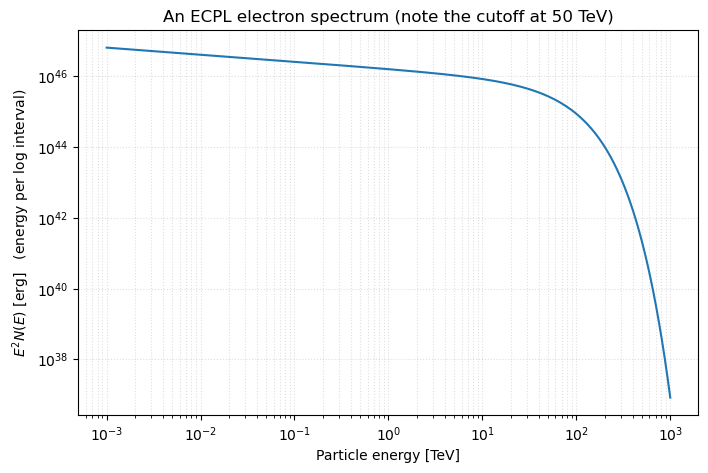

In [2]:
E0 = 1 * u.TeV
electrons = ExponentialCutoffPowerLaw(
    amplitude=1e34 / u.eV,   # N0 at E0
    e_0=E0,
    alpha=2.2,               # spectral index Gamma
    e_cutoff=50 * u.TeV,
)

Ee = np.logspace(9, 15, 200) * u.eV          # 1 GeV .. 1 PeV
NE = electrons(Ee)                            # call the distribution

fig, ax = plt.subplots()
ax.loglog(Ee.to(u.TeV), (Ee**2 * NE).to('erg'))
ax.set_xlabel('Particle energy [TeV]')
ax.set_ylabel(r'$E^2 N(E)$ [erg]   (energy per log interval)')
ax.set_title('An ECPL electron spectrum (note the cutoff at 50 TeV)')
ax.grid(which='both', ls=':', alpha=0.4); plt.show()

### How much energy is in the particles?
$W = \int E\,N(E)\,dE$. This single number -- the total energy reservoir the
source must supply -- is often the deciding physical argument. Every radiative
model carries `compute_We` / `compute_Wp` helpers for it.

In [3]:
from naima.models import InverseCompton
ic_tmp = InverseCompton(electrons, seed_photon_fields=['CMB'])
We = ic_tmp.compute_We(Eemin=1*u.GeV, Eemax=1*u.PeV)
print(f'Total electron energy We = {We.to("erg"):.3e}')

Total electron energy We = 2.763e+47 erg


## 3. Pillar 2 -- radiative processes

A radiative model takes a particle distribution (plus whatever the process needs)
and produces a photon spectrum. The four built-in processes:

| process | particles | also needs | dominates in |
|---|---|---|---|
| **Synchrotron** | electrons | magnetic field $B$ | radio - X-ray |
| **InverseCompton** | electrons | seed photon fields | X-ray - TeV |
| **Bremsstrahlung** | electrons | ambient gas density | X-ray - GeV |
| **PionDecay** | protons | ambient gas density $n_H$ | GeV - PeV |

### 3a. Leptonic processes: Synchrotron + Inverse Compton
The *same* electrons radiate by both processes. Synchrotron needs a magnetic
field; Inverse Compton needs the **seed photon fields** to scatter -- here the
CMB, the infrared dust glow and starlight (temperature + energy density each).

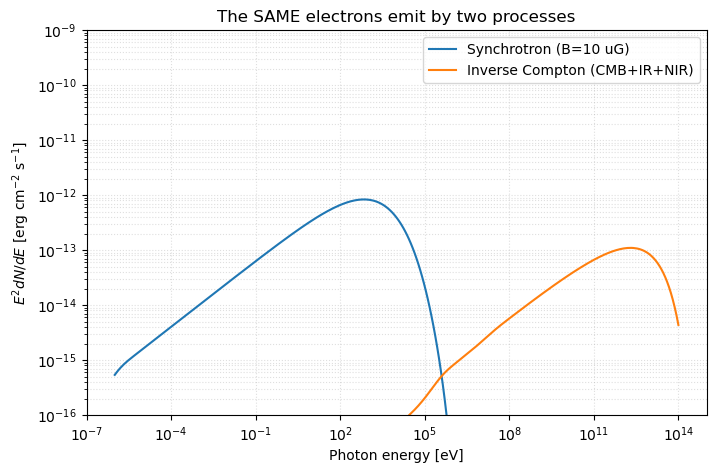

In [4]:
d = 12.5 * u.kpc
seed_fields = [
    ['CMB', 2.7 * u.K, 0.26 * u.eV / u.cm**3],
    ['FIR', 107 * u.K, 1.19 * u.eV / u.cm**3],
    ['NIR', 7906 * u.K, 1.92 * u.eV / u.cm**3],
]
sync = Synchrotron(electrons, B=10 * u.uG)
ic   = InverseCompton(electrons, seed_photon_fields=seed_fields)

Eph = np.logspace(-6, 14, 300) * u.eV         # radio (ueV) to PeV
sed_sync = (Eph**2 * sync.flux(Eph, distance=d)).to('erg/(cm2 s)')
sed_ic   = (Eph**2 * ic.flux(Eph, distance=d)).to('erg/(cm2 s)')

fig, ax = plt.subplots()
ax.loglog(Eph.to(u.eV), sed_sync, label='Synchrotron (B=10 uG)')
ax.loglog(Eph.to(u.eV), sed_ic,   label='Inverse Compton (CMB+IR+NIR)')
ax.set_xlabel('Photon energy [eV]'); ax.set_ylabel(r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.set_ylim(1e-16, 1e-9); ax.set_title('The SAME electrons emit by two processes')
ax.legend(); ax.grid(which='both', ls=':', alpha=0.4); plt.show()

### 3b. Hadronic process: Pion decay
Protons colliding with ambient gas make $\pi^0$ that decay to two photons. The
model needs the **target gas density** `nh`; the resulting gamma-ray flux scales
linearly with it (remember this -- it causes the $N_0$-$n_H$ degeneracy in the
hadronic fit).

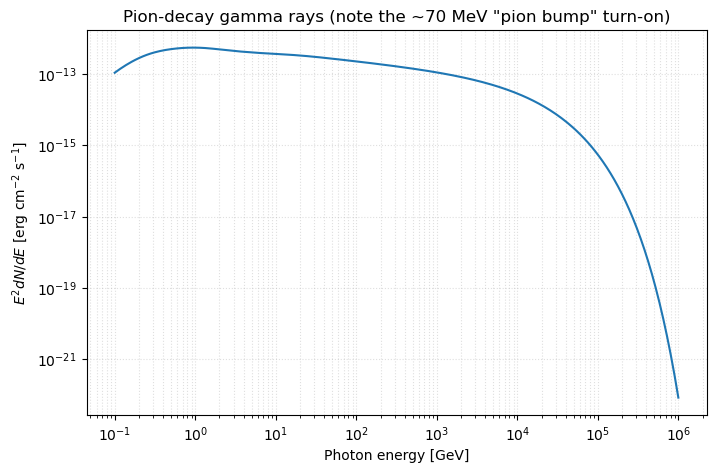

In [5]:
protons = ExponentialCutoffPowerLaw(1e36/u.eV, E0, 2.3, 100*u.TeV)
pion = PionDecay(protons, nh=10 / u.cm**3)

Eg = np.logspace(8, 15, 300) * u.eV           # 100 MeV .. 1 PeV
sed_pion = (Eg**2 * pion.flux(Eg, distance=d)).to('erg/(cm2 s)')

fig, ax = plt.subplots()
ax.loglog(Eg.to(u.GeV), sed_pion)
ax.set_xlabel('Photon energy [GeV]'); ax.set_ylabel(r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.set_title('Pion-decay gamma rays (note the ~70 MeV "pion bump" turn-on)')
ax.grid(which='both', ls=':', alpha=0.4); plt.show()

## 4. What naima needs as INPUT to *fit*

To run a fit you provide three things:

1. **A data table** (`astropy` table) with columns `energy`, `flux`,
   `flux_error` (or `flux_error_lo`/`hi`), optional bin edges, an `ul` flag for
   upper limits, and a confidence level. naima validates and standardises it.
2. **A model function** `model(pars, data)` that takes a parameter vector and
   returns the predicted flux at the data energies. *This is where your physics
   goes* -- it builds the particle distribution + radiative model from `pars`.
3. **A prior function** `lnprior(pars)` returning the log-prior (0 inside the
   allowed box, $-\infty$ outside). It encodes what parameter values are allowed.

Let's load our real data table and look at it.

columns: ['energy', 'energy_lo', 'energy_hi', 'flux', 'flux_error_lo', 'flux_error_hi', 'ul', 'instrument', 'group']
12 points, 2 upper limits


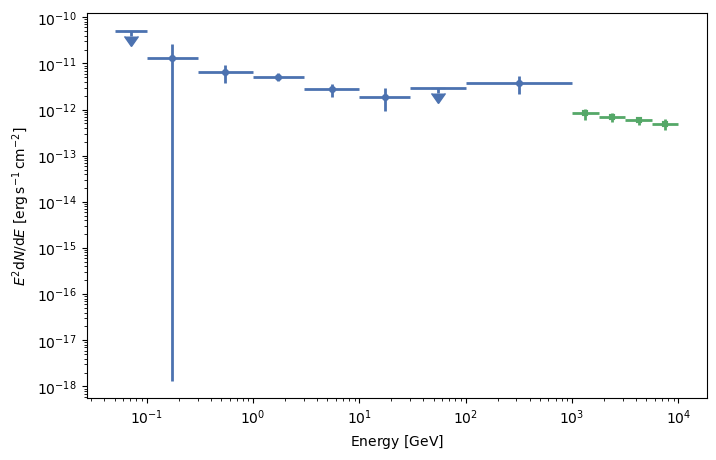

In [6]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from spectrum_tools import load_spectrum

data = load_spectrum('../spectra/combined_real_baseline.ecsv')
print('columns:', data.colnames)
print(f"{len(data)} points, {int(np.sum(data['ul']))} upper limits")
fig = naima.plot_data(data, sed=True); plt.show()

### The model and prior functions
Here is the *entire* leptonic model function (from `naima_models/leptonic.py`).
Notice the pattern: unpack `pars` -> build a particle distribution -> build a
radiative model -> return `.flux(...)`. naima will call this for every trial
parameter vector.

In [7]:
import inspect
from naima_models import leptonic as L
print(inspect.getsource(L.leptonic_model))
print(inspect.getsource(L.lnprior))

def leptonic_model(pars, data):
    """Total leptonic (IC + Synchrotron) differential photon flux at ``data``."""
    if not np.all(np.isfinite(pars)):
        return np.full(len(data), np.nan) * data["flux"].unit

    energy = data["energy"]
    models = build_models(pars)
    flux = (
        models["ic"].flux(energy, distance=CONFIG["distance"])
        + models["sync"].flux(energy, distance=CONFIG["distance"])
    )
    return flux.to(data["flux"].unit)

def lnprior(pars):
    """
    Log-prior (flat) for the leptonic ECPL parameters.

        log10(N0_e)  in [30, 45]
        Gamma_e      in [2.0, 4.5]
        log10(Ecut)  in [-1, 4]    (0.1 TeV .. 10 PeV)
    """
    log10_norm, index, log10_ecut = pars
    lp = (
        naima.uniform_prior(log10_norm, 30.0, 45.0)
        + naima.uniform_prior(index, 2.0, 4.5)
        + naima.uniform_prior(log10_ecut, -1.0, 4.0)
    )
    return lp



## 5. The fitting machinery -- how naima explores parameters

For a trial parameter vector $\theta$ naima evaluates the **log-posterior**

$$\ln P(\theta\,|\,\text{data}) \;=\; \underbrace{\ln\mathcal{L}(\text{data}\,|\,\theta)}_{=\,-\frac12\chi^2\;(+\,\text{upper-limit terms})}\;+\;\underbrace{\ln\pi(\theta)}_{\text{prior}}$$

Then the **`emcee`** sampler walks an *ensemble of walkers* through parameter
space, preferentially toward higher posterior. Key knobs:

- `nwalkers` -- size of the ensemble (must exceed $2\times$ #parameters).
- `nburn` -- *burn-in* steps, discarded while walkers migrate to the good region.
- `nrun` -- *production* steps, kept as samples of the posterior.
- `prefit=True` -- a quick optimisation first, to start walkers near the best fit.

Let's run a *tiny* fit just to see the machinery turn (not for science --
the real fits use many more steps).

In [8]:
sampler, pos = naima.run_sampler(
    data_table=data, p0=L.INITIAL, labels=L.LABELS,
    model=L.leptonic_model, prior=L.lnprior,
    nwalkers=16, nburn=10, nrun=20, threads=2, prefit=True)
print('\nchain shape (samples, parameters):', sampler.get_chain(flat=True).shape)

INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [35.62        3.08        2.62767303] [naima.core]
INFO:    Initial lnprob(p0): -8.424 [naima.core]


INFO:    New ML parameters : [35.5484873   3.00465795  2.85432981] [naima.core]
INFO:    Maximum lnprob(p0): -5.179 [naima.core]


Burning in the 16 walkers with 10 steps...



Progress of the run: 0 percent (0 of 10 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.85      
  Last ensemble std    :      0.169          0.0172          0.0126     
  Last ensemble lnprob :  avg: -13.533, max: -5.247

Progress of the run: 10 percent (1 of 10 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.86      
  Last ensemble std    :      0.15           0.0158          0.0121     
  Last ensemble lnprob :  avg: -11.260, max: -5.217

Progress of the run: 20 percent (2 of 10 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.85      
  Last ensemble std


Progress of the run: 50 percent (5 of 10 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6            3.01            2.85      
  Last ensemble std    :      0.081          0.0147          0.00811    
  Last ensemble lnprob :  avg: -7.273, max: -5.199

Progress of the run: 60 percent (6 of 10 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6            3.01            2.85      
  Last ensemble std    :     0.0777           0.019          0.00839    
  Last ensemble lnprob :  avg: -7.156, max: -5.199

Progress of the run: 70 percent (7 of 10 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.02            2.85      
  Last ensemble std 


Progress of the run: 0 percent (0 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.85      
  Last ensemble std    :     0.0639          0.0312          0.00814    
  Last ensemble lnprob :  avg: -6.495, max: -5.180

Progress of the run: 5 percent (1 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.85      
  Last ensemble std    :     0.0574          0.0335          0.00911    
  Last ensemble lnprob :  avg: -6.341, max: -5.193

Progress of the run: 10 percent (2 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5              3             2.85      
  Last ensemble std   


Progress of the run: 25 percent (5 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.86      
  Last ensemble std    :     0.0496           0.027          0.00883    
  Last ensemble lnprob :  avg: -6.120, max: -5.187

Progress of the run: 30 percent (6 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.86      
  Last ensemble std    :     0.0472          0.0267          0.00928    
  Last ensemble lnprob :  avg: -6.073, max: -5.229

Progress of the run: 35 percent (7 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5              3             2.86      
  Last ensemble std 


Progress of the run: 50 percent (10 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.86      
  Last ensemble std    :     0.0488          0.0339          0.0178     
  Last ensemble lnprob :  avg: -6.246, max: -5.181

Progress of the run: 55 percent (11 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.86      
  Last ensemble std    :     0.0529          0.0353           0.02      
  Last ensemble lnprob :  avg: -6.436, max: -5.213

Progress of the run: 60 percent (12 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.86      
  Last ensemble s


Progress of the run: 75 percent (15 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            2.98            2.87      
  Last ensemble std    :     0.0451          0.0384          0.0242     
  Last ensemble lnprob :  avg: -6.287, max: -5.250

Progress of the run: 80 percent (16 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5              3             2.86      
  Last ensemble std    :     0.0512          0.0473          0.0193     
  Last ensemble lnprob :  avg: -6.468, max: -5.209

Progress of the run: 85 percent (17 of 20 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5              3             2.86      
  Last ensemble s

## 6. What naima produces as OUTPUT

`run_sampler` returns a **sampler** object holding the full chain. From it you
get everything:

- `sampler.get_chain(flat=True)` -- the posterior samples (one row per sample).
- `sampler.get_log_prob(flat=True)` -- their log-posterior values.
- **Best fit**: the maximum-a-posteriori sample, or per-parameter percentiles.
- **Plots**: `naima.plot_fit`, `naima.plot_chain`, `naima.plot_corner`.
- **Derived physics**: `compute_We`/`compute_Wp`, propagated over the chain.

(With so few steps these are not meaningful yet -- the real notebooks do this
properly.)

$\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$    =  35.53  (+0.04 / -0.05)
$\Gamma_e$                               =   3.00  (+0.03 / -0.04)
$\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ =   2.86  (+0.02 / -0.01)


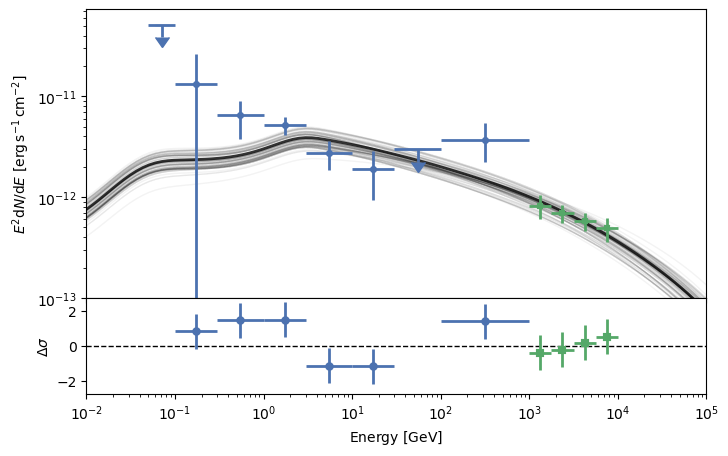

In [9]:
chain = sampler.get_chain(flat=True)
q16, q50, q84 = np.percentile(chain, [16, 50, 84], axis=0)
for lab, lo, mid, hi in zip(L.LABELS, q16, q50, q84):
    print(f'{lab:40s} = {mid:6.2f}  (+{hi-mid:.2f} / -{mid-lo:.2f})')

fig = naima.plot_fit(sampler, sed=True, e_range=[1e-2, 1e5]*u.GeV); plt.show()

## 7. The two scenarios of this project

Everything above combines into the two competing source models we fit:

### Hadronic (`naima_models/hadronic.py`)
`PionDecay(protons)` **+** co-accelerated electrons (`N0_e = Kep*N0_p`) giving
`InverseCompton` + `Synchrotron`. The protons make the gamma rays; the small
electron component is a by-product. The headline number is the **proton energy**
$W_p$.

### Leptonic (`naima_models/leptonic.py`)
A single electron population giving `InverseCompton` (+ `Synchrotron`). The
electrons make the gamma rays directly. The headline number is the **electron
energy** $W_e$.

Both are fit to the *same* data; we then compare goodness-of-fit, spectral
shape, and required energy to judge which is more plausible.

### Where to go next
- **`fit_hadronic_pion_decay.ipynb`** -- full hadronic fit, step by step.
- **`fit_leptonic_inverse_compton.ipynb`** -- full leptonic fit.
- **`plot_results.ipynb`** -- publication-style SED figures of the best fits.

### Further reading
- naima docs: https://naima.readthedocs.io
- Zabalza 2015 (the naima paper), *Proc. 34th ICRC*, arXiv:1509.03319.
- Hnatyk et al. 2022, MNRAS 516, 4196 -- the study we reproduce.